# DAM Project Notebook  
## Expanding the Feature Space for Truthfulness Classification on the LIAR Dataset

This notebook is a **full revised project notebook** for a **method / application DAM project**.  
It is written to support the following project storyline:

- **Problem:** binary truthfulness classification on the LIAR dataset
- **Baseline:** TF-IDF + Naive Bayes
- **Improvement 1:** metadata feature engineering
- **Improvement 2:** speaker-history / credibility feature engineering
- **Improvement 3:** similar-claim retrieval features using **MinHash + LSH**
- **Improvement 4:** graph-derived structural features using **PageRank**
- **Improvement 5 (optional but included):** graph embeddings from random walks in the spirit of **node2vec / graph embedding lectures**
- **Final model:** compare an improved linear model and an improved boosted-tree model

---

## Why this project is valid

The project brief allows a **method or application project** that applies existing methods and proposes improvements such as:

- enhanced features,
- refined training procedures,
- model modifications,
- careful fine-tuning,

as long as the changes are **well motivated and validated by experiments**.

This notebook follows that spirit exactly:
1. start from a simple baseline,
2. build a stronger feature space using methods connected to course topics,
3. validate the contribution through ablation experiments,
4. discuss why the added methods help or fail.

---

## Course-topic alignment

This notebook is intentionally aligned to the teaching topics:

1. **Machine learning / classification**
   - Naive Bayes baseline
   - Logistic Regression / SGD classifier
   - XGBoost as a strong final classifier for mixed engineered features

2. **Locality Sensitive Hashing (LSH)**
   - used to retrieve similar claims efficiently
   - converted into neighbor-based features for classification

3. **Graph mining / PageRank**
   - a metadata graph is built from LIAR entities
   - PageRank and degree are used as structural features

4. **Graph embedding**
   - random-walk based node embeddings are learned on the metadata graph
   - claim-level features are formed from entity embeddings

---

## Important note on scope

The original idea of using **retweet / propagation graphs** is **not compatible** with the LIAR TSV files alone, because LIAR does not provide a social diffusion network.  
Therefore, this notebook uses a **metadata graph constructed from LIAR itself**, which is a defensible and reproducible graph-mining adaptation.

---

## Binary formulation used here

The uploaded baseline notebooks use a **binary label mapping** rather than the original 6-way LIAR labels.  
To stay consistent with your current project direction, we follow that same formulation:

- **true class**: `true`, `mostly-true`, `half-true`, `barely-true`
- **false class**: `false`, `pants-fire`

This is a simplification, and you should mention it as a project design choice in the report.

In [2]:
# Step 0: Imports, configuration, and reproducibility

import os
import re
import math
import random
import hashlib
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy import sparse

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier
from sklearn.decomposition import TruncatedSVD

import networkx as nx
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


# 1. Data Loading

The LIAR dataset files are tab-separated with 14 columns.  
We assign the standard LIAR column names:

1. `id`
2. `label`
3. `statement`
4. `subject`
5. `speaker`
6. `speaker_job_title`
7. `state_info`
8. `party_affiliation`
9. `barely_true_counts`
10. `false_counts`
11. `half_true_counts`
12. `mostly_true_counts`
13. `pants_on_fire_counts`
14. `context`

We now load train / validation / test and construct the binary label used in your earlier notebooks.

In [3]:
# Step 1: Load the LIAR dataset and construct binary labels

LIAR_COLUMNS = [
    "id",
    "label",
    "statement",
    "subject",
    "speaker",
    "speaker_job_title",
    "state_info",
    "party_affiliation",
    "barely_true_counts",
    "false_counts",
    "half_true_counts",
    "mostly_true_counts",
    "pants_on_fire_counts",
    "context",
]

TRUE_GROUP = {"true", "mostly-true", "half-true", "barely-true"}
FALSE_GROUP = {"false", "pants-fire"}

def read_liar_split(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t", header=None, names=LIAR_COLUMNS)
    return df

def to_binary_label(label: str):
    if pd.isna(label):
        return None
    if label in TRUE_GROUP:
        return 1
    if label in FALSE_GROUP:
        return 0
    return None

train_path = "data/train.tsv"
valid_path = "data/valid.tsv"
test_path  = "data/test.tsv"

train_df = read_liar_split(train_path)
valid_df = read_liar_split(valid_path)
test_df  = read_liar_split(test_path)

for df in [train_df, valid_df, test_df]:
    df["y"] = df["label"].map(to_binary_label)

# Keep only rows that map into the chosen binary setting
train_df = train_df.dropna(subset=["y"]).copy()
valid_df = valid_df.dropna(subset=["y"]).copy()
test_df  = test_df.dropna(subset=["y"]).copy()

train_df["y"] = train_df["y"].astype(int)
valid_df["y"] = valid_df["y"].astype(int)
test_df["y"]  = test_df["y"].astype(int)

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)
print("Test  shape:", test_df.shape)

display(train_df.head())

Train shape: (10240, 15)
Valid shape: (1284, 15)
Test  shape: (1267, 15)


,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context,y
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer,0
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.,1
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver,1
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release,0
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN,1


### for the 6-class experiment (to compare with just 2 classes of True and False)

In [21]:
# Step 1b: Six-class label mapping
LABEL_ORDER = ["pants-fire", "false", "barely-true", "half-true", "mostly-true", "true"]
LABEL_TO_INT = {label: i for i, label in enumerate(LABEL_ORDER)}
# 0=pants-fire, 1=false, 2=barely-true, 3=half-true, 4=mostly-true, 5=true

def to_six_class_label(label: str):
    if pd.isna(label):
        return None
    return LABEL_TO_INT.get(label, None)

train_df6 = read_liar_split(train_path)
valid_df6 = read_liar_split(valid_path)
test_df6  = read_liar_split(test_path)

for df in [train_df6, valid_df6, test_df6]:
    df["y"] = df["label"].apply(to_six_class_label)
    df["statement_clean"] = df["statement"].apply(clean_text)

train_df6 = train_df6.dropna(subset=["y"]).copy()
valid_df6 = valid_df6.dropna(subset=["y"]).copy()
test_df6  = test_df6.dropna(subset=["y"]).copy()

for df in [train_df6, valid_df6, test_df6]:
    df["y"] = df["y"].astype(int)

y_train6 = train_df6["y"].values
y_valid6 = valid_df6["y"].values
y_test6  = test_df6["y"].values

print("Six-class label distribution (train):")
print(pd.Series(y_train6).value_counts().sort_index()
      .rename(index={i: l for i, l in enumerate(LABEL_ORDER)}))

Six-class label distribution (train):
pants-fire      839
false          1995
barely-true    1654
half-true      2114
mostly-true    1962
true           1676
Name: count, dtype: int64


# 2. Quick Exploratory Checks

Before modeling, we do a few sanity checks:

- class balance after binarization,
- missing values,
- statement length distribution.

These are useful for the report because they justify later design choices such as:
- text vectorization,
- metadata cleaning,
- smoothing of speaker-history features.


Train
-----
Rows: 10240
Class counts:
y
0    2834
1    7406
Name: count, dtype: int64

Missing values:
speaker_job_title       2898
state_info              2210
context                  102
speaker                    2
subject                    2
barely_true_counts         2
party_affiliation          2
false_counts               2
half_true_counts           2
mostly_true_counts         2
pants_on_fire_counts       2
dtype: int64

Validation
----------
Rows: 1284
Class counts:
y
0    379
1    905
Name: count, dtype: int64

Missing values:
speaker_job_title    345
state_info           279
context               12
dtype: int64

Test
----
Rows: 1267
Class counts:
y
0    341
1    926
Name: count, dtype: int64

Missing values:
speaker_job_title    325
state_info           262
context               17
dtype: int64


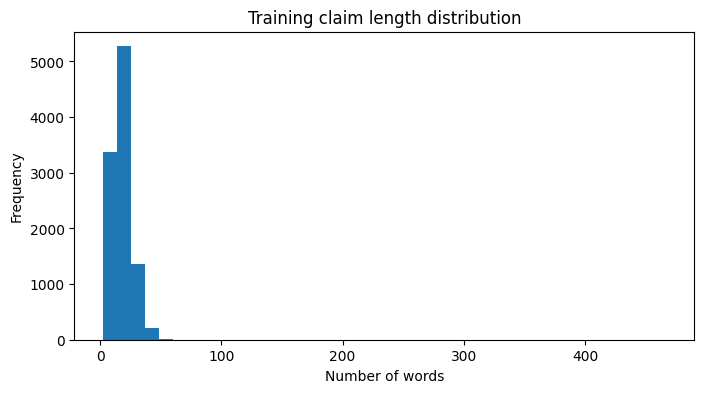

In [4]:
# Step 2: Basic exploratory analysis

def summarize_split(df: pd.DataFrame, name: str):
    print(f"\n{name}")
    print("-" * len(name))
    print("Rows:", len(df))
    print("Class counts:")
    print(df["y"].value_counts().sort_index())
    print("\nMissing values:")
    print(df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False))

summarize_split(train_df, "Train")
summarize_split(valid_df, "Validation")
summarize_split(test_df, "Test")

for df in [train_df, valid_df, test_df]:
    df["statement_len_words"] = df["statement"].fillna("").str.split().apply(len)

plt.figure(figsize=(8, 4))
plt.hist(train_df["statement_len_words"], bins=40)
plt.title("Training claim length distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

# 3. Text Preprocessing

We use a light text normalization:

- lowercase,
- keep letters, numbers, and apostrophes,
- collapse extra whitespace.

We intentionally avoid aggressive lemmatization or stemming here because:
1. the claims are short,
2. the metadata and engineered features will already add signal,
3. simpler preprocessing is easier to reproduce and explain.

In [5]:
# Step 3: Text cleaning utilities

def clean_text(text: str) -> str:
    text = "" if pd.isna(text) else str(text)
    text = text.lower()
    text = re.sub(r"[^a-z0-9' ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for df in [train_df, valid_df, test_df]:
    df["statement_clean"] = df["statement"].apply(clean_text)

display(train_df[["statement", "statement_clean"]].head())

,statement,statement_clean
0,Says the Annies List political group supports ...,says the annies list political group supports ...
1,When did the decline of coal start? It started...,when did the decline of coal start it started ...
2,"Hillary Clinton agrees with John McCain ""by vo...",hillary clinton agrees with john mccain by vot...
3,Health care reform legislation is likely to ma...,health care reform legislation is likely to ma...
4,The economic turnaround started at the end of ...,the economic turnaround started at the end of ...


# 4. Baseline: TF-IDF + Multinomial Naive Bayes

We begin with a text-only baseline built from the cleaned claim statement. Each claim is represented by unigram and bigram TF-IDF features, and a Multinomial Naive Bayes classifier is trained on that sparse representation.

## 4.1 Model Formulation

Let a document be represented by a vector $x = (x_1, x_2, \dots, x_V)$, where $x_j$ denotes the weight of term $j$ and $V$ is the vocabulary size. Under the multinomial Naive Bayes model, where $w_j$ represents the j-th word/term in the vocabulary:

$$
P(x \mid y) = \prod_{j=1}^{V} P(w_j \mid y)^{x_j}.
$$

By Bayes' rule,

$$
P(y \mid x) = \frac{P(y)\,P(x \mid y)}{P(x)}.
$$

Since $P(x)$ does not depend on the class label, the prediction rule can be written as

$$
\hat{y} = \arg\max_{y} P(y)\,P(x \mid y).
$$

Taking logarithms gives the additive decision function

$$
\hat{y} = \arg\max_{y} \left( \log P(y) + \sum_{j=1}^{V} x_j \log P(w_j \mid y) \right).
$$

This additive form is attractive for high-dimensional sparse text because each term contributes independently to the final class score.

## 4.2 Role of the Baseline

The baseline serves as the text-only reference point for the rest of the notebook. It tells us how much predictive signal can be extracted from the wording of the claim alone, before any metadata, retrieval-based, or graph-derived information is introduced.

The conditional independence assumption is clearly simplified for natural language, since words in a sentence are not truly independent. Even so, the model remains useful here because it is efficient, reproducible, and often competitive on sparse bag-of-words representations. More importantly, it provides a clear reference for evaluating how much the later feature-space expansions improve the task.


Baseline performance
Validation Accuracy : 0.7165
Validation Precision: 0.7180
Validation Recall   : 0.9845
Validation F1       : 0.8304
Test Accuracy : 0.7301
Test Precision: 0.7378
Test Recall   : 0.9784
Test F1       : 0.8412

Classification report on test:
              precision    recall  f1-score   support

           0     0.4872    0.0557    0.1000       341
           1     0.7378    0.9784    0.8412       926

    accuracy                         0.7301      1267
   macro avg     0.6125    0.5171    0.4706      1267
weighted avg     0.6703    0.7301    0.6417      1267



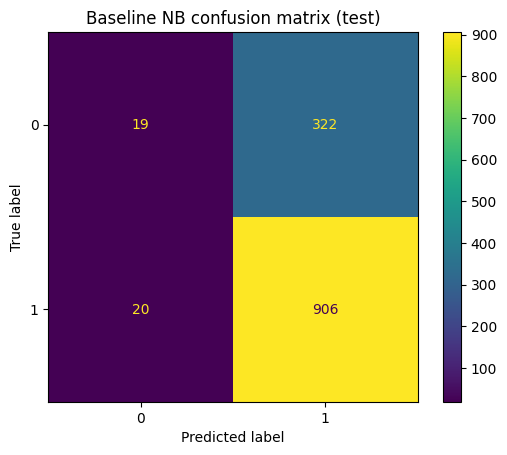

In [6]:
# Step 4: Baseline model - TF-IDF + Multinomial Naive Bayes

baseline_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=20000,
    sublinear_tf=True,
)

X_train_text = baseline_vectorizer.fit_transform(train_df["statement_clean"])
X_valid_text = baseline_vectorizer.transform(valid_df["statement_clean"])
X_test_text  = baseline_vectorizer.transform(test_df["statement_clean"])

y_train = train_df["y"].values
y_valid = valid_df["y"].values
y_test  = test_df["y"].values

baseline_nb = MultinomialNB(alpha=0.5)
baseline_nb.fit(X_train_text, y_train)

valid_pred_nb = baseline_nb.predict(X_valid_text)
test_pred_nb  = baseline_nb.predict(X_test_text)

def evaluate_predictions(y_true, y_pred, split_name="Split"):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    print(f"{split_name} Accuracy : {acc:.4f}")
    print(f"{split_name} Precision: {p:.4f}")
    print(f"{split_name} Recall   : {r:.4f}")
    print(f"{split_name} F1       : {f1:.4f}")
    return {"accuracy": acc, "precision": p, "recall": r, "f1": f1}

print("Baseline performance")
baseline_valid_metrics = evaluate_predictions(y_valid, valid_pred_nb, "Validation")
baseline_test_metrics  = evaluate_predictions(y_test, test_pred_nb, "Test")

print("\nClassification report on test:")
print(classification_report(y_test, test_pred_nb, digits=4))

ConfusionMatrixDisplay.from_predictions(y_test, test_pred_nb)
plt.title("Baseline NB confusion matrix (test)")
plt.show()

### 6-class experiment

In [22]:
# Six-class baseline: TF-IDF + Multinomial Naive Bayes
vectorizer6 = TfidfVectorizer(
    ngram_range=(1, 2), min_df=2, max_features=20000, sublinear_tf=True
)
X_train6 = vectorizer6.fit_transform(train_df6["statement_clean"])
X_valid6  = vectorizer6.transform(valid_df6["statement_clean"])
X_test6   = vectorizer6.transform(test_df6["statement_clean"])

nb6 = MultinomialNB(alpha=0.5)
nb6.fit(X_train6, y_train6)
test_pred_nb6 = nb6.predict(X_test6)

print("Six-class NB — Test Report:")
print(classification_report(
    y_test6, test_pred_nb6,
    target_names=LABEL_ORDER, digits=4
))

Six-class NB — Test Report:
              precision    recall  f1-score   support

  pants-fire     0.0000    0.0000    0.0000        92
       false     0.2640    0.3414    0.2977       249
 barely-true     0.2636    0.1368    0.1801       212
   half-true     0.2190    0.3396    0.2663       265
 mostly-true     0.2375    0.3154    0.2709       241
        true     0.2692    0.1346    0.1795       208

    accuracy                         0.2431      1267
   macro avg     0.2089    0.2113    0.1991      1267
weighted avg     0.2312    0.2431    0.2253      1267



In [23]:
# Comparison table: Binary vs Six-class NB
from sklearn.metrics import f1_score

binary_acc = accuracy_score(y_test, test_pred_nb)
binary_macro_f1 = f1_score(y_test, test_pred_nb, average="macro")
binary_weighted_f1 = f1_score(y_test, test_pred_nb, average="weighted")

six_acc = accuracy_score(y_test6, test_pred_nb6)
six_macro_f1 = f1_score(y_test6, test_pred_nb6, average="macro")
six_weighted_f1 = f1_score(y_test6, test_pred_nb6, average="weighted")

comparison_df = pd.DataFrame({
    "Setting":       ["Binary (2-class)", "Six-class"],
    "# Classes":     [2, 6],
    "Random Chance": ["50.0%", "16.7%"],
    "Accuracy":      [f"{binary_acc:.4f}", f"{six_acc:.4f}"],
    "Macro-F1":      [f"{binary_macro_f1:.4f}", f"{six_macro_f1:.4f}"],
    "Weighted-F1":   [f"{binary_weighted_f1:.4f}", f"{six_weighted_f1:.4f}"],
})

display(comparison_df)

,Setting,# Classes,Random Chance,Accuracy,Macro-F1,Weighted-F1
0,Binary (2-class),2,50.0%,0.7301,0.4706,0.6417
1,Six-class,6,16.7%,0.2431,0.1991,0.2253


# 5. Improvement 1: Metadata + Speaker-History Features

The first major feature-space expansion introduces information that is already present in LIAR, but not yet expressed in a form that a classifier can use directly and effectively.

## 5.1 Feature Construction

We use the following categorical metadata fields:
- `subject`
- `speaker`
- `speaker_job_title`
- `state_info`
- `party_affiliation`
- `context`

After cleaning missing values and grouping rare categories, these fields are encoded with one-hot encoding.

In addition, the dataset provides five speaker-history count fields:
- `barely_true_counts`
- `false_counts`
- `half_true_counts`
- `mostly_true_counts`
- `pants_on_fire_counts`

From these raw counts, we derive aggregate and ratio-based features such as:
- total historical fact-check count,
- false-oriented ratio,
- true-oriented ratio,
- extreme-false ratio,
- smoothed credibility-style scores,
- claim length in words.

## 5.2 Why These Features Matter

A claim is not determined by wording alone. The same topic may be associated with different reliability patterns across speakers, contexts, and affiliations. Similarly, the raw count history of a speaker can be transformed into prior evidence about how that speaker has been evaluated in earlier fact-checks.

The important point is that the improvement lies in the **engineered representation**, not merely in the existence of the raw columns. The notebook converts categorical, numeric, and historical information into a structured feature space that can be combined with the text representation.

## 5.3 Expected Effect

These features are intended to address a limitation of the baseline: a text-only model may miss useful context when two claims are lexically similar but come from very different speakers or political settings. Metadata and speaker-history features help the model distinguish such cases more effectively.


In [7]:
# Step 5: Metadata and speaker-history feature engineering

CATEGORICAL_COLS = [
    "subject",
    "speaker",
    "speaker_job_title",
    "state_info",
    "party_affiliation",
    "context",
]

HISTORY_COLS = [
    "barely_true_counts",
    "false_counts",
    "half_true_counts",
    "mostly_true_counts",
    "pants_on_fire_counts",
]

def fill_and_trim_categories(df: pd.DataFrame, min_freq: int = 3) -> pd.DataFrame:
    df = df.copy()

    for col in CATEGORICAL_COLS:
        values = df[col].fillna("UNKNOWN").astype(str).str.strip().replace("", "UNKNOWN")
        counts = values.value_counts()
        rare = set(counts[counts < min_freq].index)
        values = values.apply(lambda x: "OTHER" if x in rare else x)
        df[col] = values

    for col in HISTORY_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)

    return df

def add_history_features(df: pd.DataFrame, alpha: float = 1.0) -> pd.DataFrame:
    df = df.copy()

    b = df["barely_true_counts"].astype(float)
    f = df["false_counts"].astype(float)
    h = df["half_true_counts"].astype(float)
    m = df["mostly_true_counts"].astype(float)
    p = df["pants_on_fire_counts"].astype(float)

    total = b + f + h + m + p

    df["history_total"] = total
    df["false_ratio"] = (f + p) / np.where(total > 0, total, 1.0)
    df["trueish_ratio"] = (b + h + m) / np.where(total > 0, total, 1.0)
    df["extreme_false_ratio"] = p / np.where(total > 0, total, 1.0)
    df["credibility_smoothed"] = (b + h + m + alpha) / (total + 2 * alpha)

    # A simple polarity-like score:
    # positive mass minus negative mass, normalized by history volume
    df["history_balance"] = ((b + h + m) - (f + p)) / np.where(total > 0, total, 1.0)

    return df

train_meta = add_history_features(fill_and_trim_categories(train_df))
valid_meta = add_history_features(fill_and_trim_categories(valid_df))
test_meta  = add_history_features(fill_and_trim_categories(test_df))

NUMERIC_ENGINEERED_COLS = [
    "history_total",
    "false_ratio",
    "trueish_ratio",
    "extreme_false_ratio",
    "credibility_smoothed",
    "history_balance",
    "statement_len_words",
]

display(train_meta[CATEGORICAL_COLS + NUMERIC_ENGINEERED_COLS].head())

,subject,speaker,speaker_job_title,state_info,party_affiliation,context,history_total,false_ratio,trueish_ratio,extreme_false_ratio,credibility_smoothed,history_balance,statement_len_words
0,abortion,OTHER,State representative,Texas,republican,a mailer,1.0,1.000000,0.000000,0.000000,0.333333,-1.000000,11
1,OTHER,OTHER,State delegate,Virginia,democrat,a floor speech.,2.0,0.000000,1.000000,0.000000,0.750000,1.000000,24
2,foreign-policy,barack-obama,President,Illinois,democrat,Denver,473.0,0.169133,0.830867,0.019027,0.829474,0.661734,19
3,health-care,blog-posting,UNKNOWN,UNKNOWN,none,a news release,78.0,0.807692,0.192308,0.564103,0.200000,-0.615385,12
4,"economy,jobs",charlie-crist,UNKNOWN,Florida,democrat,an interview on CNN,65.0,0.169231,0.830769,0.030769,0.820896,0.661538,10


# 6. First Improved Model: Text + Metadata + History

We now combine:
- TF-IDF text features,
- one-hot encoded metadata,
- scaled numeric engineered features.

A linear classifier is a strong first improved model because:
- text features are sparse and high-dimensional,
- one-hot metadata is also sparse,
- linear models are efficient and interpretable in this setting.

We use `SGDClassifier(loss="log_loss")`, which is effectively a scalable logistic-regression-style classifier for large sparse feature matrices.

In [8]:
# Step 6: Improved linear model using text + metadata + history

preprocessor_linear = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_features=20000,
                sublinear_tf=True,
            ),
            "statement_clean",
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            CATEGORICAL_COLS,
        ),
        (
            "num",
            StandardScaler(with_mean=False),
            NUMERIC_ENGINEERED_COLS,
        ),
    ],
    remainder="drop",
)

linear_model = SGDClassifier(
    loss="log_loss",
    alpha=1e-5,
    max_iter=2000,
    tol=1e-4,
    random_state=RANDOM_STATE,
)

linear_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor_linear),
        ("model", linear_model),
    ]
)

linear_pipeline.fit(train_meta, y_train)

valid_pred_linear = linear_pipeline.predict(valid_meta)
test_pred_linear  = linear_pipeline.predict(test_meta)

print("Improved linear model performance")
linear_valid_metrics = evaluate_predictions(y_valid, valid_pred_linear, "Validation")
linear_test_metrics  = evaluate_predictions(y_test, test_pred_linear, "Test")

print("\nClassification report on test:")
print(classification_report(y_test, test_pred_linear, digits=4))

Improved linear model performance
Validation Accuracy : 0.7967
Validation Precision: 0.8404
Validation Recall   : 0.8785
Validation F1       : 0.8590
Test Accuracy : 0.7885
Test Precision: 0.8378
Test Recall   : 0.8812
Test F1       : 0.8589

Classification report on test:
              precision    recall  f1-score   support

           0     0.6246    0.5367    0.5773       341
           1     0.8378    0.8812    0.8589       926

    accuracy                         0.7885      1267
   macro avg     0.7312    0.7089    0.7181      1267
weighted avg     0.7804    0.7885    0.7831      1267



# 7. Improvement 2: Similar-Claim Features Using MinHash + LSH

This section adds retrieval-based features so that each claim can benefit from information about similar claims in the training set.

## 7.1 Motivation

Many claims in political fact-checking data are repeated, paraphrased, or slightly reworded versions of earlier talking points. A purely supervised text classifier treats each example independently, even though a new claim may be closely related to previously seen statements.

To capture this local neighborhood structure, we retrieve similar claims and summarize their relationship to the current claim as numerical features.

## 7.2 Jaccard Similarity

Each cleaned claim is represented as a set of word shingles. Given two claims represented by sets $A$ and $B$, their Jaccard similarity is

$$
J(A,B) = \frac{|A \cap B|}{|A \cup B|}.
$$

This measure is well suited to duplicate and near-duplicate detection because it evaluates overlap relative to total size.

## 7.3 MinHash

Directly comparing all claim pairs with Jaccard similarity is expensive. MinHash provides an efficient approximation. For a random permutation $\pi$, the MinHash value of a set $S$ is

$$
h_\pi(S) = \min(\pi(S)).
$$

A key property is

$$
\Pr[h_\pi(A) = h_\pi(B)] = J(A,B).
$$

This means that collision frequency under random hashing reflects set similarity. By using multiple hash functions, each claim receives a compact signature that approximates its similarity relationships.

## 7.4 Locality Sensitive Hashing

The signatures are further organized with Locality Sensitive Hashing. Instead of comparing every signature with every other signature, LSH places signature bands into buckets and only treats bucket collisions as candidate neighbors. This reduces the amount of pairwise comparison while preserving likely similar pairs.

## 7.5 Derived Retrieval Features

The retrieved neighbors are not used to assign labels directly. Instead, they are summarized into claim-level features such as:
- number of candidate neighbors,
- maximum Jaccard similarity,
- mean similarity among the top matches,
- fraction of matched neighbors that belong to the positive class.

These summaries are then appended to the rest of the feature space. In this way, the classifier benefits from similar-claim evidence without leaving the supervised classification setting.


In [9]:
# Step 7: MinHash + LSH utilities for similar-claim features

# Initialise a reproducible MinHash + LSH pipeline for similar-claim retrieval.

LARGE_PRIME = 4294967311

def stable_token_hash(token: str) -> int:
    return int(hashlib.md5(token.encode("utf-8")).hexdigest(), 16) % LARGE_PRIME

def make_word_shingles(text: str, k: int = 3):
    words = text.split()
    if len(words) < k:
        return set(words) if words else {"<EMPTY>"}
    return {" ".join(words[i:i+k]) for i in range(len(words) - k + 1)}

def generate_hash_params(num_perm: int, seed: int = RANDOM_STATE):
    rng = np.random.default_rng(seed)
    a = rng.integers(1, LARGE_PRIME - 1, size=num_perm, dtype=np.int64)
    b = rng.integers(0, LARGE_PRIME - 1, size=num_perm, dtype=np.int64)
    return a, b

HASH_A, HASH_B = generate_hash_params(num_perm=64)

def minhash_signature(shingle_set, hash_a=HASH_A, hash_b=HASH_B):
    if not shingle_set:
        shingle_set = {"<EMPTY>"}
    tokens = np.array([stable_token_hash(t) for t in shingle_set], dtype=np.int64)
    sig = np.full(len(hash_a), LARGE_PRIME, dtype=np.int64)
    for token_hash in tokens:
        values = (hash_a * token_hash + hash_b) % LARGE_PRIME
        sig = np.minimum(sig, values)
    return sig

def build_lsh_index(signatures, bands: int = 8, rows_per_band: int = 8):
    assert bands * rows_per_band == signatures.shape[1], "bands * rows_per_band must equal signature length."
    buckets = defaultdict(list)

    for idx, sig in enumerate(signatures):
        for band in range(bands):
            start = band * rows_per_band
            end = start + rows_per_band
            band_tuple = tuple(sig[start:end].tolist())
            bucket_key = (band, band_tuple)
            buckets[bucket_key].append(idx)

    return buckets

def candidate_indices(query_sig, buckets, bands: int = 8, rows_per_band: int = 8):
    cands = set()
    for band in range(bands):
        start = band * rows_per_band
        end = start + rows_per_band
        band_tuple = tuple(query_sig[start:end].tolist())
        bucket_key = (band, band_tuple)
        cands.update(buckets.get(bucket_key, []))
    return cands

def jaccard_similarity(set_a, set_b):
    denom = len(set_a | set_b)
    if denom == 0:
        return 0.0
    return len(set_a & set_b) / denom

In [10]:
# Step 8: Build MinHash signatures and derive retrieval features

def prepare_shingles(df: pd.DataFrame, shingle_k: int = 3):
    return [make_word_shingles(text, k=shingle_k) for text in df["statement_clean"]]

train_shingles = prepare_shingles(train_meta, shingle_k=3)
valid_shingles = prepare_shingles(valid_meta, shingle_k=3)
test_shingles  = prepare_shingles(test_meta, shingle_k=3)

train_signatures = np.vstack([minhash_signature(s) for s in train_shingles])
valid_signatures = np.vstack([minhash_signature(s) for s in valid_shingles])
test_signatures  = np.vstack([minhash_signature(s) for s in test_shingles])

lsh_buckets = build_lsh_index(train_signatures, bands=8, rows_per_band=8)

train_y_series = pd.Series(y_train)

def neighbor_features_for_query(
    query_shingles,
    query_sig,
    buckets,
    reference_shingles,
    reference_labels,
    exclude_index=None,
    top_k=5,
):
    cands = candidate_indices(query_sig, buckets, bands=8, rows_per_band=8)

    if exclude_index is not None and exclude_index in cands:
        cands.remove(exclude_index)

    if not cands:
        return {
            "lsh_candidate_count": 0.0,
            "lsh_max_jaccard": 0.0,
            "lsh_mean_topk_jaccard": 0.0,
            "lsh_topk_true_rate": 0.5,
            "lsh_topk_label_std": 0.0,
        }

    sims = []
    for idx in cands:
        sim = jaccard_similarity(query_shingles, reference_shingles[idx])
        if sim > 0:
            sims.append((idx, sim))

    if not sims:
        return {
            "lsh_candidate_count": float(len(cands)),
            "lsh_max_jaccard": 0.0,
            "lsh_mean_topk_jaccard": 0.0,
            "lsh_topk_true_rate": 0.5,
            "lsh_topk_label_std": 0.0,
        }

    sims.sort(key=lambda x: x[1], reverse=True)
    top = sims[:top_k]

    top_sims = [s for _, s in top]
    top_labels = [reference_labels[idx] for idx, _ in top]

    return {
        "lsh_candidate_count": float(len(cands)),
        "lsh_max_jaccard": float(max(top_sims)),
        "lsh_mean_topk_jaccard": float(np.mean(top_sims)),
        "lsh_topk_true_rate": float(np.mean(top_labels)),
        "lsh_topk_label_std": float(np.std(top_labels)),
    }

# Train features use leave-one-out style retrieval from the same train index.
train_lsh_features = []
for i in range(len(train_meta)):
    feats = neighbor_features_for_query(
        query_shingles=train_shingles[i],
        query_sig=train_signatures[i],
        buckets=lsh_buckets,
        reference_shingles=train_shingles,
        reference_labels=y_train,
        exclude_index=i,
        top_k=5,
    )
    train_lsh_features.append(feats)

valid_lsh_features = []
for i in range(len(valid_meta)):
    feats = neighbor_features_for_query(
        query_shingles=valid_shingles[i],
        query_sig=valid_signatures[i],
        buckets=lsh_buckets,
        reference_shingles=train_shingles,
        reference_labels=y_train,
        exclude_index=None,
        top_k=5,
    )
    valid_lsh_features.append(feats)

test_lsh_features = []
for i in range(len(test_meta)):
    feats = neighbor_features_for_query(
        query_shingles=test_shingles[i],
        query_sig=test_signatures[i],
        buckets=lsh_buckets,
        reference_shingles=train_shingles,
        reference_labels=y_train,
        exclude_index=None,
        top_k=5,
    )
    test_lsh_features.append(feats)

train_lsh_df = pd.DataFrame(train_lsh_features)
valid_lsh_df = pd.DataFrame(valid_lsh_features)
test_lsh_df  = pd.DataFrame(test_lsh_features)

display(train_lsh_df.head())

,lsh_candidate_count,lsh_max_jaccard,lsh_mean_topk_jaccard,lsh_topk_true_rate,lsh_topk_label_std
0,0.0,0.0,0.0,0.5,0.0
1,0.0,0.0,0.0,0.5,0.0
2,0.0,0.0,0.0,0.5,0.0
3,0.0,0.0,0.0,0.5,0.0
4,0.0,0.0,0.0,0.5,0.0


In [11]:
# Step 9: Merge LSH features back into the working dataframes

train_plus = train_meta.reset_index(drop=True).copy()
valid_plus = valid_meta.reset_index(drop=True).copy()
test_plus  = test_meta.reset_index(drop=True).copy()

for col in train_lsh_df.columns:
    train_plus[col] = train_lsh_df[col].values
    valid_plus[col] = valid_lsh_df[col].values
    test_plus[col]  = test_lsh_df[col].values

LSH_FEATURE_COLS = list(train_lsh_df.columns)

display(train_plus[LSH_FEATURE_COLS].describe().T)

,count,mean,std,min,25%,50%,75%,max
lsh_candidate_count,10240.0,0.005664,0.085968,0.0,0.0,0.0,0.0,2.0
lsh_max_jaccard,10240.0,0.004499,0.065466,0.0,0.0,0.0,0.0,1.0
lsh_mean_topk_jaccard,10240.0,0.004499,0.065466,0.0,0.0,0.0,0.0,1.0
lsh_topk_true_rate,10240.0,0.499854,0.033147,0.0,0.5,0.5,0.5,1.0
lsh_topk_label_std,10240.0,0.000195,0.009881,0.0,0.0,0.0,0.0,0.5


# 8. Improvement 3: Graph-Derived Features Using PageRank

The next feature family represents LIAR as a metadata graph so that structural relationships among entities can be used for classification.

## 8.1 Metadata Graph Construction

The dataset does not provide a true propagation graph or social sharing network. Instead, we construct a graph directly from the metadata fields that LIAR contains. Nodes correspond to entities such as:
- speakers,
- subjects,
- parties,
- states.

Edges are added when entities co-occur within the same claim record. This produces a heterogeneous metadata graph in which connectivity reflects recurring associations inside the dataset itself.

## 8.2 Why Graph Structure Can Help

A flat tabular encoding treats each metadata field separately. A graph representation adds another view: it captures how entities relate to one another across the whole dataset. For example, a speaker may be linked repeatedly to certain subjects or affiliations, and those repeated associations may create structural patterns that are useful for classification.

## 8.3 PageRank

One of the main graph-derived statistics used here is PageRank. If $M$ is a suitable transition matrix and $\beta \in (0,1)$ is the damping factor, the PageRank vector $r$ satisfies

$$
r = \beta M r + (1-\beta) v,
$$

where $v$ is the teleportation distribution.

In this setting, PageRank does not represent social influence or diffusion. Instead, it measures structural prominence inside the metadata graph built from LIAR.

## 8.4 Claim-Level Graph Features

Once node statistics are computed, they are mapped back to each claim through the claim's associated entities. This gives each claim additional numerical features such as speaker-level or subject-level graph scores. These graph-derived features complement both the text features and the one-hot metadata representation.


In [12]:
# Step 10: Build metadata graph and derive PageRank features

def split_subjects(subject_value):
    if pd.isna(subject_value):
        return []
    # LIAR subjects may contain comma-separated values.
    parts = [s.strip() for s in str(subject_value).split(",")]
    return [p for p in parts if p]

def build_metadata_graph(df: pd.DataFrame) -> nx.Graph:
    G = nx.Graph()

    for _, row in df.iterrows():
        speaker = f"speaker::{row['speaker']}" if pd.notna(row["speaker"]) else None
        party   = f"party::{row['party_affiliation']}" if pd.notna(row["party_affiliation"]) else None
        state   = f"state::{row['state_info']}" if pd.notna(row["state_info"]) else None
        subs    = [f"subject::{s}" for s in split_subjects(row["subject"])]

        entity_nodes = [x for x in [speaker, party, state] if x is not None] + subs
        entity_nodes = list(dict.fromkeys(entity_nodes))  # remove duplicates while preserving order

        for node in entity_nodes:
            G.add_node(node)

        # Fully connect the entities appearing in one claim (small co-occurrence clique)
        for i in range(len(entity_nodes)):
            for j in range(i + 1, len(entity_nodes)):
                u, v = entity_nodes[i], entity_nodes[j]
                if G.has_edge(u, v):
                    G[u][v]["weight"] += 1.0
                else:
                    G.add_edge(u, v, weight=1.0)

    return G

metadata_graph = build_metadata_graph(train_plus)
print("Metadata graph nodes:", metadata_graph.number_of_nodes())
print("Metadata graph edges:", metadata_graph.number_of_edges())

pagerank_scores = nx.pagerank(metadata_graph, weight="weight")
degree_scores = dict(metadata_graph.degree())

def graph_features_for_row(row, pr_scores, deg_scores):
    speaker_node = f"speaker::{row['speaker']}" if pd.notna(row["speaker"]) else None
    party_node   = f"party::{row['party_affiliation']}" if pd.notna(row["party_affiliation"]) else None
    state_node   = f"state::{row['state_info']}" if pd.notna(row["state_info"]) else None
    subject_nodes = [f"subject::{s}" for s in split_subjects(row["subject"])]

    subj_pr = [pr_scores.get(n, 0.0) for n in subject_nodes] if subject_nodes else [0.0]
    subj_deg = [deg_scores.get(n, 0.0) for n in subject_nodes] if subject_nodes else [0.0]

    return {
        "graph_speaker_pagerank": pr_scores.get(speaker_node, 0.0),
        "graph_party_pagerank": pr_scores.get(party_node, 0.0),
        "graph_state_pagerank": pr_scores.get(state_node, 0.0),
        "graph_subject_pagerank_mean": float(np.mean(subj_pr)),
        "graph_speaker_degree": float(deg_scores.get(speaker_node, 0.0)),
        "graph_subject_degree_mean": float(np.mean(subj_deg)),
    }

train_graph_df = pd.DataFrame([graph_features_for_row(row, pagerank_scores, degree_scores) for _, row in train_plus.iterrows()])
valid_graph_df = pd.DataFrame([graph_features_for_row(row, pagerank_scores, degree_scores) for _, row in valid_plus.iterrows()])
test_graph_df  = pd.DataFrame([graph_features_for_row(row, pagerank_scores, degree_scores) for _, row in test_plus.iterrows()])

for col in train_graph_df.columns:
    train_plus[col] = train_graph_df[col].values
    valid_plus[col] = valid_graph_df[col].values
    test_plus[col]  = test_graph_df[col].values

GRAPH_FEATURE_COLS = list(train_graph_df.columns)

display(train_plus[GRAPH_FEATURE_COLS].head())

Metadata graph nodes: 834
Metadata graph edges: 8912


,graph_speaker_pagerank,graph_party_pagerank,graph_state_pagerank,graph_subject_pagerank_mean,graph_speaker_degree,graph_subject_degree_mean
0,0.047395,0.087212,0.020329,0.003492,184.0,126.0
1,0.047395,0.066597,0.008678,0.066349,184.0,603.0
2,0.008183,0.066597,0.009709,0.005049,66.0,123.0
3,0.001211,0.033281,0.042644,0.015543,35.0,328.0
4,0.001395,0.066597,0.019484,0.011683,26.0,255.5


# 9. Improvement 4: Graph Embedding Features

Graph-derived scalar features such as degree and PageRank summarize only selected aspects of graph structure. This section adds learned graph embeddings to capture richer structural patterns.

## 9.1 Random Walks

The metadata graph is first explored through random walks. A random walk is a sequence of nodes produced by repeatedly moving from one node to one of its neighbors. These walks act as structural contexts: nodes that frequently appear in similar walk neighborhoods should receive similar vector representations.

## 9.2 Embedding Learning

The generated walks are treated analogously to sentences, and a Word2Vec-style model is trained on them. If a node $u$ is mapped to an embedding vector

$$
u \mapsto z_u \in \mathbb{R}^d,
$$

then nodes with similar graph neighborhoods should obtain nearby vectors in the learned space.

## 9.3 Claim-Level Embedding Features

After learning the node embeddings, the relevant embeddings for entities associated with each claim are attached back to the claim as dense numerical features. These vectors allow the final classifier to use richer graph structure than would be available from scalar centrality measures alone.


In [13]:
# Step 11: Random-walk graph embeddings (node2vec-style)

from gensim.models import Word2Vec

def node2vec_walk(G, start_node, walk_length=20, p=1.0, q=1.0, rng=None):
    if rng is None:
        rng = random.Random(RANDOM_STATE)

    walk = [start_node]

    while len(walk) < walk_length:
        cur = walk[-1]
        neighbors = list(G.neighbors(cur))
        if not neighbors:
            break

        if len(walk) == 1:
            walk.append(rng.choice(neighbors))
        else:
            prev = walk[-2]
            weights = []
            for nbr in neighbors:
                if nbr == prev:
                    weights.append(1.0 / p)
                elif G.has_edge(nbr, prev):
                    weights.append(1.0)
                else:
                    weights.append(1.0 / q)

            total = sum(weights)
            probs = [w / total for w in weights]
            next_node = rng.choices(neighbors, weights=probs, k=1)[0]
            walk.append(next_node)

    return walk

def generate_walks(G, num_walks=10, walk_length=20, p=1.0, q=1.0, seed=RANDOM_STATE):
    rng = random.Random(seed)
    nodes = list(G.nodes())
    walks = []

    for _ in range(num_walks):
        rng.shuffle(nodes)
        for node in nodes:
            walks.append(node2vec_walk(G, node, walk_length=walk_length, p=p, q=q, rng=rng))

    return walks

walks = generate_walks(metadata_graph, num_walks=8, walk_length=20, p=1.0, q=1.0, seed=RANDOM_STATE)

embedding_dim = 16
w2v_model = Word2Vec(
    sentences=walks,
    vector_size=embedding_dim,
    window=5,
    min_count=1,
    sg=1,
    workers=1,
    epochs=10,
    seed=RANDOM_STATE,
)

def get_node_embedding(node_name, model, dim=embedding_dim):
    if node_name in model.wv:
        return model.wv[node_name]
    return np.zeros(dim, dtype=float)

def graph_embedding_features_for_row(row, model, dim=embedding_dim):
    speaker_node = f"speaker::{row['speaker']}" if pd.notna(row["speaker"]) else None
    party_node   = f"party::{row['party_affiliation']}" if pd.notna(row["party_affiliation"]) else None
    state_node   = f"state::{row['state_info']}" if pd.notna(row["state_info"]) else None
    subject_nodes = [f"subject::{s}" for s in split_subjects(row["subject"])]

    speaker_emb = get_node_embedding(speaker_node, model, dim)
    party_emb   = get_node_embedding(party_node, model, dim)
    state_emb   = get_node_embedding(state_node, model, dim)

    if subject_nodes:
        subject_embs = np.vstack([get_node_embedding(n, model, dim) for n in subject_nodes])
        subject_mean = subject_embs.mean(axis=0)
    else:
        subject_mean = np.zeros(dim, dtype=float)

    feats = {}
    for i in range(dim):
        feats[f"emb_speaker_{i}"] = float(speaker_emb[i])
        feats[f"emb_party_{i}"] = float(party_emb[i])
        feats[f"emb_state_{i}"] = float(state_emb[i])
        feats[f"emb_subject_mean_{i}"] = float(subject_mean[i])

    return feats

train_emb_df = pd.DataFrame([graph_embedding_features_for_row(row, w2v_model, embedding_dim) for _, row in train_plus.iterrows()])
valid_emb_df = pd.DataFrame([graph_embedding_features_for_row(row, w2v_model, embedding_dim) for _, row in valid_plus.iterrows()])
test_emb_df  = pd.DataFrame([graph_embedding_features_for_row(row, w2v_model, embedding_dim) for _, row in test_plus.iterrows()])

for col in train_emb_df.columns:
    train_plus[col] = train_emb_df[col].values
    valid_plus[col] = valid_emb_df[col].values
    test_plus[col]  = test_emb_df[col].values

EMBEDDING_FEATURE_COLS = list(train_emb_df.columns)

print("Number of graph embedding features:", len(EMBEDDING_FEATURE_COLS))
display(train_plus[EMBEDDING_FEATURE_COLS[:8]].head())

Number of graph embedding features: 64


,emb_speaker_0,emb_party_0,emb_state_0,emb_subject_mean_0,emb_speaker_1,emb_party_1,emb_state_1,emb_subject_mean_1
0,0.521061,0.233882,0.620723,-0.028691,-0.006317,-0.147661,0.043154,-0.347295
1,0.521061,0.103471,0.120591,-0.127635,-0.006317,-0.027585,0.440765,-0.380076
2,0.574940,0.103471,0.713759,-0.585316,0.203557,-0.027585,0.010602,0.126025
3,0.313153,0.293737,0.228271,-0.180114,-0.268446,-0.376645,-0.474613,-0.096417
4,0.309387,0.103471,0.669554,-0.216467,0.281058,-0.027585,-0.117445,-0.028870


# 10. Final Improved Models

After all feature groups have been constructed, the notebook evaluates two final model families.

## 10.1 Enhanced Linear Model

The enhanced linear model keeps the sparse linear classification setting while using the expanded feature space. This tests whether the added metadata, retrieval, and graph information is already strong enough to improve performance within a relatively simple classifier family.

## 10.2 Enhanced XGBoost Model

The XGBoost model is trained on a Truncated SVD representation of the full mixed-feature space. This model is intended to exploit non-linear interactions among feature groups, especially once text, metadata, similarity-based, and graph-derived signals are combined.

Together, these two models help answer two complementary questions:
- how much improvement comes from the enriched representation itself,
- and whether a more flexible learner can extract additional value from that richer representation.


In [14]:
# Step 12: Final feature groups

FINAL_NUMERIC_COLS = (
    NUMERIC_ENGINEERED_COLS
    + LSH_FEATURE_COLS
    + GRAPH_FEATURE_COLS
    + EMBEDDING_FEATURE_COLS
)

print("Numeric engineered feature count:", len(FINAL_NUMERIC_COLS))

Numeric engineered feature count: 82


In [15]:
# Step 13: Enhanced linear model with all feature groups

preprocessor_final_linear = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_features=25000,
                sublinear_tf=True,
            ),
            "statement_clean",
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            CATEGORICAL_COLS,
        ),
        (
            "num",
            StandardScaler(with_mean=False),
            FINAL_NUMERIC_COLS,
        ),
    ],
    remainder="drop",
)

final_linear_model = SGDClassifier(
    loss="log_loss",
    alpha=5e-6,
    max_iter=2500,
    tol=1e-4,
    random_state=RANDOM_STATE,
)

final_linear_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor_final_linear),
        ("model", final_linear_model),
    ]
)

final_linear_pipeline.fit(train_plus, y_train)

valid_pred_final_linear = final_linear_pipeline.predict(valid_plus)
test_pred_final_linear  = final_linear_pipeline.predict(test_plus)

print("Final enhanced linear model performance")
final_linear_valid_metrics = evaluate_predictions(y_valid, valid_pred_final_linear, "Validation")
final_linear_test_metrics  = evaluate_predictions(y_test, test_pred_final_linear, "Test")

Final enhanced linear model performance
Validation Accuracy : 0.8022
Validation Precision: 0.7883
Validation Recall   : 0.9834
Validation F1       : 0.8751
Test Accuracy : 0.7995
Test Precision: 0.7984
Test Recall   : 0.9708
Test F1       : 0.8762


In [16]:
# Step 14: XGBoost final model using SVD-compressed features

# Step 1: build a sparse matrix from text + categorical + numeric features
preprocessor_xgb = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_features=25000,
                sublinear_tf=True,
            ),
            "statement_clean",
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            CATEGORICAL_COLS,
        ),
        (
            "num",
            StandardScaler(with_mean=False),
            FINAL_NUMERIC_COLS,
        ),
    ],
    remainder="drop",
)

X_train_sparse = preprocessor_xgb.fit_transform(train_plus)
X_valid_sparse = preprocessor_xgb.transform(valid_plus)
X_test_sparse  = preprocessor_xgb.transform(test_plus)

print("Sparse feature matrix shape (train):", X_train_sparse.shape)

# Step 2: compress the sparse matrix to a manageable dense representation
svd = TruncatedSVD(n_components=300, random_state=RANDOM_STATE)
X_train_dense = svd.fit_transform(X_train_sparse)
X_valid_dense = svd.transform(X_valid_sparse)
X_test_dense  = svd.transform(X_test_sparse)

print("Dense SVD feature matrix shape (train):", X_train_dense.shape)
print("Explained variance ratio sum:", svd.explained_variance_ratio_.sum())

# Step 3: fit XGBoost on the dense reduced representation
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
)

xgb_model.fit(X_train_dense, y_train)

valid_pred_xgb = (xgb_model.predict_proba(X_valid_dense)[:, 1] >= 0.5).astype(int)
test_pred_xgb  = (xgb_model.predict_proba(X_test_dense)[:, 1] >= 0.5).astype(int)

print("XGBoost final model performance")
xgb_valid_metrics = evaluate_predictions(y_valid, valid_pred_xgb, "Validation")
xgb_test_metrics  = evaluate_predictions(y_test, test_pred_xgb, "Test")

Sparse feature matrix shape (train): (10240, 27120)
Dense SVD feature matrix shape (train): (10240, 300)
Explained variance ratio sum: 0.9793489059044295
XGBoost final model performance
Validation Accuracy : 0.7928
Validation Precision: 0.8123
Validation Recall   : 0.9182
Validation F1       : 0.8620
Test Accuracy : 0.8003
Test Precision: 0.8239
Test Recall   : 0.9244
Test F1       : 0.8712


## ablation study on xgboost

In [24]:
# Step 15: Ablation Study on XGBoost pipeline

def run_xgb_ablation(train_data, valid_data, test_data, y_train, y_valid, y_test,
                     exclude_transformers=None, label="Full Model"):
    """
    Runs the full XGBoost pipeline with specified transformers excluded.
    exclude_transformers: list of transformer names to drop, e.g. ["lsh", "graph"]
    Transformer names match those defined in ColumnTransformer: "text", "cat", "num_history", "num_lsh", "num_graph"
    """

    transformers = []

    if "text" not in (exclude_transformers or []):
        transformers.append((
            "text",
            TfidfVectorizer(ngram_range=(1,2), min_df=2, max_features=25000, sublinear_tf=True),
            "statement_clean",
        ))

    if "cat" not in (exclude_transformers or []):
        transformers.append((
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            CATEGORICAL_COLS,
        ))

    # Split numeric features into separate named groups so we can drop them individually
    history_cols = NUMERIC_ENGINEERED_COLS  # metadata + speaker history
    lsh_cols     = LSH_FEATURE_COLS
    graph_cols   = GRAPH_FEATURE_COLS + EMBEDDING_FEATURE_COLS

    if "metadata" not in (exclude_transformers or []):
        transformers.append((
            "num_history",
            StandardScaler(with_mean=False),
            history_cols,
        ))

    if "lsh" not in (exclude_transformers or []):
        transformers.append((
            "num_lsh",
            StandardScaler(with_mean=False),
            lsh_cols,
        ))

    if "graph" not in (exclude_transformers or []):
        transformers.append((
            "num_graph",
            StandardScaler(with_mean=False),
            graph_cols,
        ))

    preprocessor = ColumnTransformer(transformers=transformers, remainder="drop")

    X_train_sp = preprocessor.fit_transform(train_data)
    X_valid_sp = preprocessor.transform(valid_data)
    X_test_sp  = preprocessor.transform(test_data)

    # Determine SVD components — can't exceed feature count
    n_components = min(300, X_train_sp.shape[1] - 1)

    svd_ = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)
    X_train_d = svd_.fit_transform(X_train_sp)
    X_valid_d = svd_.transform(X_valid_sp)
    X_test_d  = svd_.transform(X_test_sp)

    xgb_ = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        verbosity=0,
    )
    xgb_.fit(X_train_d, y_train)

    test_pred  = (xgb_.predict_proba(X_test_d)[:, 1] >= 0.5).astype(int)

    acc      = accuracy_score(y_test, test_pred)
    macro_f1 = f1_score(y_test, test_pred, average="macro")
    f1_bin   = f1_score(y_test, test_pred, average="binary")
    recall_false = precision_recall_fscore_support(y_test, test_pred, average=None, zero_division=0)[1][0]

    print(f"[{label}] Accuracy: {acc:.4f} | Binary-F1: {f1_bin:.4f} | Macro-F1: {macro_f1:.4f} | False-Recall: {recall_false:.4f}")

    return {
        "Model": label,
        "Accuracy": round(acc, 4),
        "Binary-F1": round(f1_bin, 4),
        "Macro-F1": round(macro_f1, 4),
        "False-Class Recall": round(recall_false, 4),
    }

# Define ablation runs
ablation_configs = [
    (None,          "Full Model (all features)"),
    (["text"],      "No Text"),
    (["cat"],       "No Metadata Categories"),
    (["metadata"],  "No Speaker History"),
    (["lsh"],       "No LSH Features"),
    (["graph"],     "No Graph Features"),
]

ablation_results = []
for exclude, label in ablation_configs:
    result = run_xgb_ablation(
        train_plus, valid_plus, test_plus,
        y_train, y_valid, y_test,
        exclude_transformers=exclude,
        label=label,
    )
    ablation_results.append(result)

ablation_df = pd.DataFrame(ablation_results)
display(ablation_df)

[Full Model (all features)] Accuracy: 0.8003 | Binary-F1: 0.8712 | Macro-F1: 0.7133 | False-Recall: 0.4633
[No Text] Accuracy: 0.7916 | Binary-F1: 0.8650 | Macro-F1: 0.7041 | False-Recall: 0.4604
[No Metadata Categories] Accuracy: 0.7987 | Binary-F1: 0.8705 | Macro-F1: 0.7096 | False-Recall: 0.4545
[No Speaker History] Accuracy: 0.7435 | Binary-F1: 0.8426 | Macro-F1: 0.5748 | False-Recall: 0.2111
[No LSH Features] Accuracy: 0.7987 | Binary-F1: 0.8706 | Macro-F1: 0.7088 | False-Recall: 0.4516
[No Graph Features] Accuracy: 0.8011 | Binary-F1: 0.8712 | Macro-F1: 0.7176 | False-Recall: 0.4780


,Model,Accuracy,Binary-F1,Macro-F1,False-Class Recall
0,Full Model (all features),0.8003,0.8712,0.7133,0.4633
1,No Text,0.7916,0.8650,0.7041,0.4604
2,No Metadata Categories,0.7987,0.8705,0.7096,0.4545
3,No Speaker History,0.7435,0.8426,0.5748,0.2111
4,No LSH Features,0.7987,0.8706,0.7088,0.4516
5,No Graph Features,0.8011,0.8712,0.7176,0.4780


# 11. Consolidated Comparison Table

This table is important for the report.  
A good DAM project should not only show a final best number, but also demonstrate **which feature groups actually contribute**.

The comparison below lets you answer questions such as:
- Does metadata help beyond text-only?
- Do speaker-history features matter?
- Does LSH-style similar-claim retrieval add measurable signal?
- Do graph features justify their extra complexity?
- Does a boosted tree beat a strong linear model?

These are exactly the types of insights the report discussion should emphasize.

In [25]:
# Compute predicted probabilities for AUC-ROC
from sklearn.metrics import roc_auc_score

prob_nb           = baseline_nb.predict_proba(X_test_text)[:, 1]
prob_linear       = linear_pipeline.predict_proba(test_meta)[:, 1]
prob_final_linear = final_linear_pipeline.predict_proba(test_plus)[:, 1]
prob_xgb          = xgb_model.predict_proba(X_test_dense)[:, 1]

In [28]:
# Step 15: Consolidated results table
results_df = pd.DataFrame([
    {
        "model": "Baseline: TF-IDF + Naive Bayes",
        "valid_accuracy": baseline_valid_metrics["accuracy"],
        "valid_f1": baseline_valid_metrics["f1"],
        "test_accuracy": baseline_test_metrics["accuracy"],
        "test_f1": baseline_test_metrics["f1"],
        "test_auc_roc": roc_auc_score(y_test, prob_nb),
    },
    {
        "model": "Improved Linear: text + metadata + history",
        "valid_accuracy": linear_valid_metrics["accuracy"],
        "valid_f1": linear_valid_metrics["f1"],
        "test_accuracy": linear_test_metrics["accuracy"],
        "test_f1": linear_test_metrics["f1"],
        "test_auc_roc": roc_auc_score(y_test, prob_linear),
    },
    {
        "model": "Final Linear: + LSH + graph + embeddings",
        "valid_accuracy": final_linear_valid_metrics["accuracy"],
        "valid_f1": final_linear_valid_metrics["f1"],
        "test_accuracy": final_linear_test_metrics["accuracy"],
        "test_f1": final_linear_test_metrics["f1"],
        "test_auc_roc": roc_auc_score(y_test, prob_final_linear),
    },
    {
        "model": "Final XGBoost: SVD(text+all features)",
        "valid_accuracy": xgb_valid_metrics["accuracy"],
        "valid_f1": xgb_valid_metrics["f1"],
        "test_accuracy": xgb_test_metrics["accuracy"],
        "test_f1": xgb_test_metrics["f1"],
        "test_auc_roc": roc_auc_score(y_test, prob_xgb),
    },
])

results_df = results_df.sort_values(by=["test_accuracy", "test_auc_roc"], ascending=False).reset_index(drop=True)
display(results_df)

,model,valid_accuracy,valid_f1,test_accuracy,test_f1,test_auc_roc
0,Final XGBoost: SVD(text+all features),0.792835,0.862033,0.800316,0.871247,0.814879
1,Final Linear: + LSH + graph + embeddings,0.802181,0.875123,0.799526,0.876218,0.812173
2,Improved Linear: text + metadata + history,0.796729,0.858995,0.788477,0.858947,0.813726
3,Baseline: TF-IDF + Naive Bayes,0.716511,0.830382,0.730071,0.841226,0.660239


# 12. Comparative Visualizations

The following plots complement the result tables by showing:
- class imbalance across dataset splits,
- confusion-matrix changes from the baseline to the strongest model,
- model-level performance comparisons,
- and staged performance as additional feature groups are introduced.


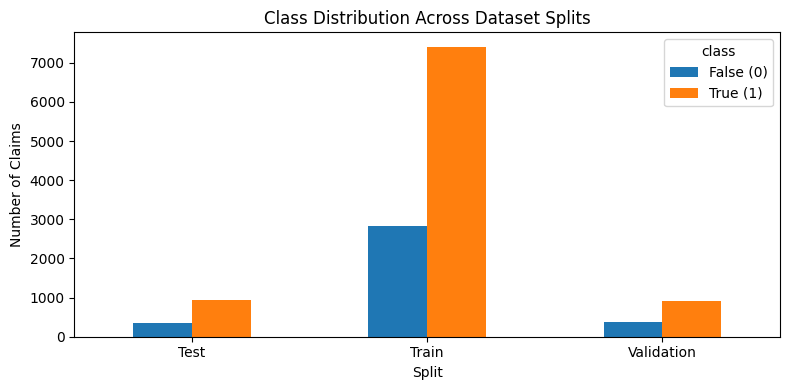

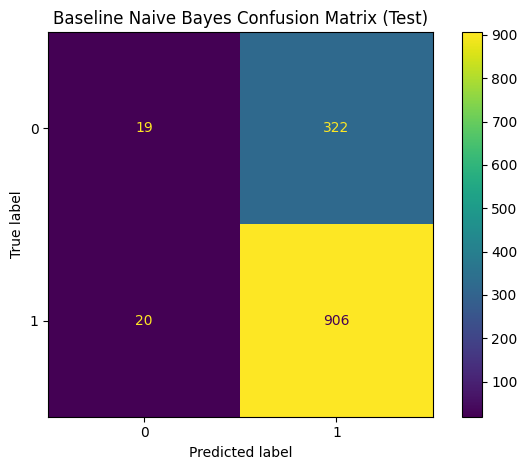

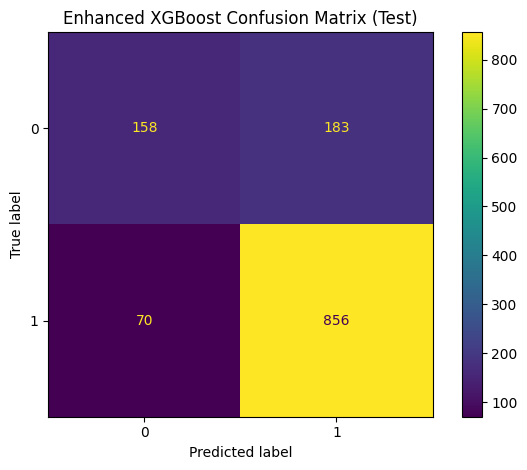

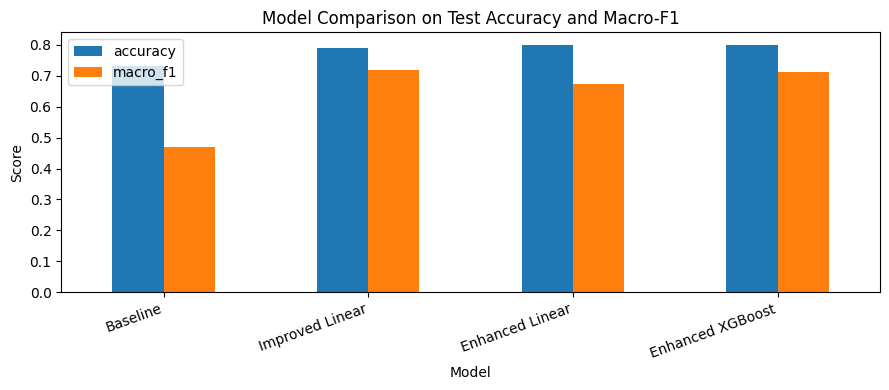

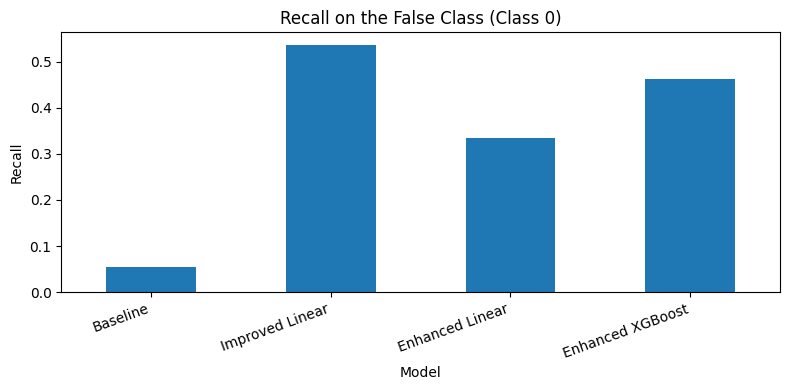

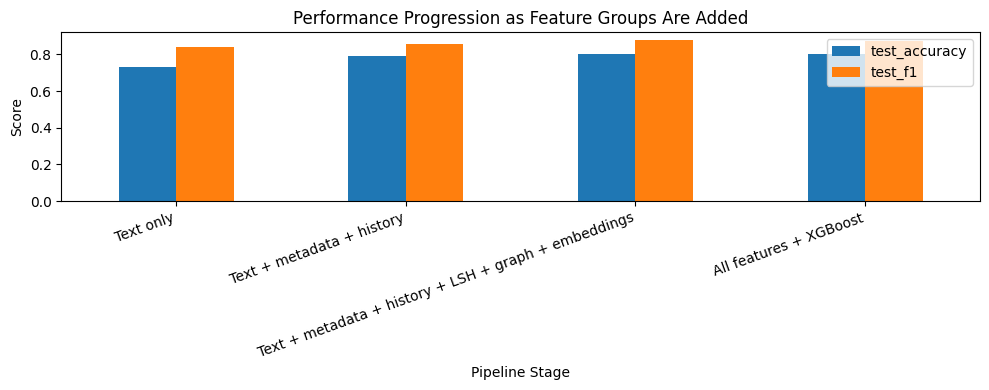

,model,accuracy,macro_f1,class0_recall,class1_f1
0,Baseline,0.7301,0.4706,0.0557,0.8412
1,Improved Linear,0.7885,0.7181,0.5367,0.8589
2,Enhanced Linear,0.7995,0.6746,0.3343,0.8762
3,Enhanced XGBoost,0.8003,0.7133,0.4633,0.8712


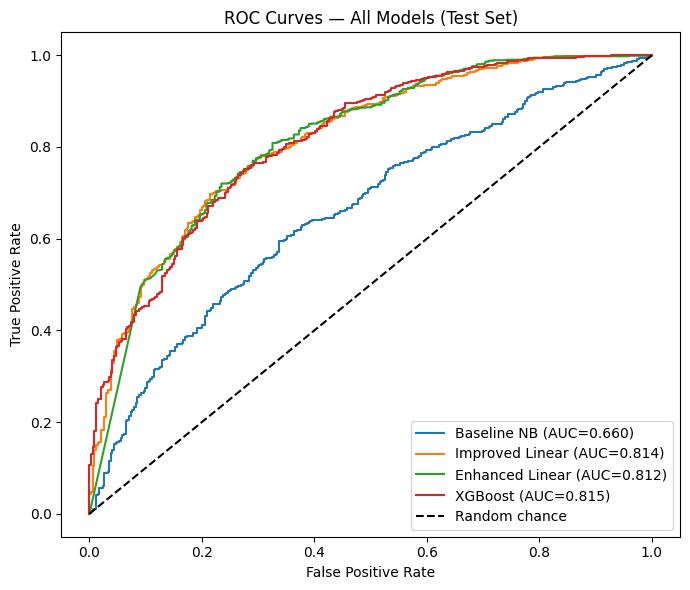

In [27]:
# Step 16: Build comparative visualizations for class balance, confusion matrices, and model performance

from sklearn.metrics import precision_recall_fscore_support

# 1) Class balance across train / validation / test
class_balance_df = pd.DataFrame({
    "split": ["Train", "Train", "Validation", "Validation", "Test", "Test"],
    "class": ["False (0)", "True (1)", "False (0)", "True (1)", "False (0)", "True (1)"],
    "count": [
        int((y_train == 0).sum()), int((y_train == 1).sum()),
        int((y_valid == 0).sum()), int((y_valid == 1).sum()),
        int((y_test == 0).sum()),  int((y_test == 1).sum()),
    ],
})

pivot_balance = class_balance_df.pivot(index="split", columns="class", values="count")
pivot_balance.plot(kind="bar", figsize=(8, 4))
plt.title("Class Distribution Across Dataset Splits")
plt.xlabel("Split")
plt.ylabel("Number of Claims")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 2) Confusion matrices: baseline vs best final model
ConfusionMatrixDisplay.from_predictions(y_test, test_pred_nb)
plt.title("Baseline Naive Bayes Confusion Matrix (Test)")
plt.tight_layout()
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, test_pred_xgb)
plt.title("Enhanced XGBoost Confusion Matrix (Test)")
plt.tight_layout()
plt.show()

# 3) Build a richer comparison table for plotting
def collect_plot_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    _, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    _, recall_by_class, f1_by_class, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1], average=None, zero_division=0
    )
    return {
        "accuracy": acc,
        "macro_f1": f1_macro,
        "class0_recall": recall_by_class[0],
        "class1_f1": f1_by_class[1],
    }

plot_metrics_df = pd.DataFrame([
    {"model": "Baseline", **collect_plot_metrics(y_test, test_pred_nb)},
    {"model": "Improved Linear", **collect_plot_metrics(y_test, test_pred_linear)},
    {"model": "Enhanced Linear", **collect_plot_metrics(y_test, test_pred_final_linear)},
    {"model": "Enhanced XGBoost", **collect_plot_metrics(y_test, test_pred_xgb)},
])

# 4) Accuracy and macro-F1 comparison
plot_metrics_df.set_index("model")[["accuracy", "macro_f1"]].plot(kind="bar", figsize=(9, 4))
plt.title("Model Comparison on Test Accuracy and Macro-F1")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# 5) Minority-class recall comparison
plot_metrics_df.set_index("model")[["class0_recall"]].plot(kind="bar", figsize=(8, 4), legend=False)
plt.title("Recall on the False Class (Class 0)")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# 6) Feature-group progression chart
progression_df = pd.DataFrame([
    {"stage": "Text only", "test_accuracy": baseline_test_metrics["accuracy"], "test_f1": baseline_test_metrics["f1"]},
    {"stage": "Text + metadata + history", "test_accuracy": linear_test_metrics["accuracy"], "test_f1": linear_test_metrics["f1"]},
    {"stage": "Text + metadata + history + LSH + graph + embeddings", "test_accuracy": final_linear_test_metrics["accuracy"], "test_f1": final_linear_test_metrics["f1"]},
    {"stage": "All features + XGBoost", "test_accuracy": xgb_test_metrics["accuracy"], "test_f1": xgb_test_metrics["f1"]},
])

progression_df.set_index("stage")[["test_accuracy", "test_f1"]].plot(kind="bar", figsize=(10, 4))
plt.title("Performance Progression as Feature Groups Are Added")
plt.xlabel("Pipeline Stage")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

display(plot_metrics_df.round(4))

# 6b) ROC curves for all models
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(7, 6))
for prob, label in [
    (prob_nb,           f"Baseline NB (AUC={roc_auc_score(y_test, prob_nb):.3f})"),
    (prob_linear,       f"Improved Linear (AUC={roc_auc_score(y_test, prob_linear):.3f})"),
    (prob_final_linear, f"Enhanced Linear (AUC={roc_auc_score(y_test, prob_final_linear):.3f})"),
    (prob_xgb,          f"XGBoost (AUC={roc_auc_score(y_test, prob_xgb):.3f})"),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, label=label)

ax.plot([0, 1], [0, 1], "k--", label="Random chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models (Test Set)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()


# 13. Error Analysis

This section inspects qualitative error patterns after the quantitative comparisons have been made. The main goal is to identify:
- examples that the baseline misses but the stronger models recover,
- examples that remain difficult even after feature-space expansion,
- whether remaining errors are associated with ambiguous wording, missing context, rare entities, or hard factual distinctions.


In [19]:
# Step 16: Error analysis utilities

error_analysis_df = test_plus[[
    "statement",
    "statement_clean",
    "speaker",
    "subject",
    "party_affiliation",
    "context",
    "label",
    "y",
]].copy()

error_analysis_df["baseline_pred"] = test_pred_nb
error_analysis_df["final_linear_pred"] = test_pred_final_linear
error_analysis_df["xgb_pred"] = test_pred_xgb

# Cases improved by the final linear model over the baseline
improved_cases = error_analysis_df[
    (error_analysis_df["baseline_pred"] != error_analysis_df["y"]) &
    (error_analysis_df["final_linear_pred"] == error_analysis_df["y"])
].copy()

# Cases still wrong for the final linear model
still_wrong_cases = error_analysis_df[
    error_analysis_df["final_linear_pred"] != error_analysis_df["y"]
].copy()

print("Examples improved over baseline:", len(improved_cases))
print("Examples still wrong for final linear model:", len(still_wrong_cases))

display(improved_cases.head(10))
display(still_wrong_cases.head(10))

Examples improved over baseline: 121
Examples still wrong for final linear model: 254


,statement,statement_clean,speaker,subject,party_affiliation,context,label,y,baseline_pred,final_linear_pred,xgb_pred
2,Says John McCain has done nothing to help the ...,says john mccain has done nothing to help the ...,donald-trump,OTHER,republican,OTHER,false,0,1,0,0
12,Denali is the Kenyan word for black power.,denali is the kenyan word for black power,viral-image,environment,none,OTHER,pants-fire,0,1,0,0
16,Unfortunately we have documented instances whe...,unfortunately we have documented instances whe...,OTHER,OTHER,republican,OTHER,pants-fire,0,1,0,0
37,"In Massachusetts, Scott Brown pushed for a law...",in massachusetts scott brown pushed for a law ...,jeanne-shaheen,OTHER,democrat,OTHER,mostly-true,1,0,1,1
54,When undocumented children are picked up at th...,when undocumented children are picked up at th...,OTHER,OTHER,republican,OTHER,false,0,1,0,0
80,Rebuilding three high schools will benefit 40 ...,rebuilding three high schools will benefit 40 ...,OTHER,education,none,OTHER,pants-fire,0,1,0,0
95,Says people in Africa literally walk two and t...,says people in africa literally walk two and t...,OTHER,elections,republican,OTHER,pants-fire,0,1,0,0
97,Half of children struck by cars near schools a...,half of children struck by cars near schools a...,OTHER,transportation,none,OTHER,false,0,1,0,0
100,Putting three Republicans in my Cabinet...is u...,putting three republicans in my cabinet is unp...,barack-obama,history,democrat,a news conference,true,1,0,1,1
119,Says state Senate President Stephen Sweeney ga...,says state senate president stephen sweeney ga...,OTHER,OTHER,none,OTHER,false,0,1,0,0


,statement,statement_clean,speaker,subject,party_affiliation,context,label,y,baseline_pred,final_linear_pred,xgb_pred
1,Wisconsin is on pace to double the number of l...,wisconsin is on pace to double the number of l...,OTHER,jobs,democrat,a news conference,false,0,1,1,1
4,When asked by a reporter whether hes at the ce...,when asked by a reporter whether hes at the ce...,state-democratic-party-wisconsin,OTHER,democrat,a web video,pants-fire,0,0,1,0
13,Says 57 percent of federal spending goes to th...,says 57 percent of federal spending goes to th...,facebook-posts,OTHER,none,a meme on social media,false,0,1,1,1
19,Ronald Reagan faced an even worse recession th...,ronald reagan faced an even worse recession th...,sarah-palin,OTHER,republican,OTHER,false,0,1,1,1
22,The number of illegal immigrants could be 3 mi...,the number of illegal immigrants could be 3 mi...,donald-trump,immigration,republican,OTHER,pants-fire,0,1,1,1
24,Says Charlie Crist is embroiled in a fraud cas...,says charlie crist is embroiled in a fraud cas...,republican-party-florida,OTHER,republican,a TV ad,false,0,0,1,1
30,Its been since 1888 that a Senate of a differe...,its been since 1888 that a senate of a differe...,OTHER,OTHER,republican,OTHER,false,0,1,1,1
31,"Under Rosemary Lehmberg, the Travis County D.A...",under rosemary lehmberg the travis county d a ...,sarah-palin,"crime,criminal-justice",republican,OTHER,false,0,1,1,1
42,Says he won the second debate with Hillary Cli...,says he won the second debate with hillary cli...,donald-trump,OTHER,republican,a tweet,pants-fire,0,1,1,1
48,A proposed tax to fund transportation projects...,a proposed tax to fund transportation projects...,OTHER,transportation,republican,OTHER,false,0,1,1,0


# 14. Exported Outputs

The final cell saves the key result tables so that they can be reused in the report or presentation. This keeps the notebook reproducible and makes it easier to transfer results into the written deliverables.


In [20]:
# Step 17: Save results to CSV if desired

output_dir = "data/liar_project_outputs"
os.makedirs(output_dir, exist_ok=True)

results_df.to_csv(os.path.join(output_dir, "model_comparison.csv"), index=False)
improved_cases.to_csv(os.path.join(output_dir, "improved_cases.csv"), index=False)
still_wrong_cases.to_csv(os.path.join(output_dir, "still_wrong_cases.csv"), index=False)

print("Saved outputs to:", output_dir)

Saved outputs to: data/liar_project_outputs


### threshold tuning

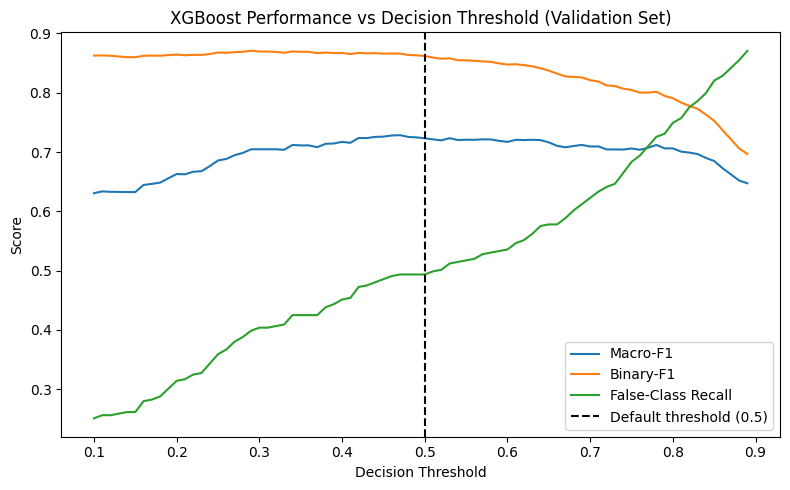

Best threshold by Macro-F1: 0.47
Validation Macro-F1 at best threshold: 0.7285
Validation False-Recall at best threshold: 0.4934

Test results at threshold=0.47:
              precision    recall  f1-score   support

           0     0.7260    0.4428    0.5501       341
           1     0.8206    0.9384    0.8756       926

    accuracy                         0.8051      1267
   macro avg     0.7733    0.6906    0.7128      1267
weighted avg     0.7951    0.8051    0.7880      1267

Side-by-side comparison (Test Set):


,Setting,Threshold,Accuracy,Binary-F1,Macro-F1,False-Recall
0,XGBoost default (t=0.50),0.50,0.8003,0.8712,0.7133,0.4633
1,XGBoost tuned (t=0.47),0.47,0.8051,0.8756,0.7128,0.4428


In [30]:
# Step 18: Threshold tuning on XGBoost using validation set

from sklearn.metrics import roc_curve, f1_score, precision_recall_fscore_support

# Get probabilities on validation set
prob_xgb_valid = xgb_model.predict_proba(X_valid_dense)[:, 1]
prob_xgb_test  = xgb_model.predict_proba(X_test_dense)[:, 1]

# Sweep thresholds from 0.1 to 0.9 and record macro-F1 on validation set
thresholds = np.arange(0.1, 0.9, 0.01)
results_thresh = []

for t in thresholds:
    preds = (prob_xgb_valid >= t).astype(int)
    macro_f1     = f1_score(y_valid, preds, average="macro", zero_division=0)
    binary_f1    = f1_score(y_valid, preds, average="binary", zero_division=0)
    _, recall, _, _ = precision_recall_fscore_support(
        y_valid, preds, average=None, zero_division=0
    )
    false_recall = recall[0] if len(recall) > 1 else 0.0
    results_thresh.append({
        "threshold": round(t, 2),
        "macro_f1": macro_f1,
        "binary_f1": binary_f1,
        "false_recall": false_recall,
    })

thresh_df = pd.DataFrame(results_thresh)

# Plot macro-F1, binary-F1, and false-class recall vs threshold
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresh_df["threshold"], thresh_df["macro_f1"],    label="Macro-F1")
ax.plot(thresh_df["threshold"], thresh_df["binary_f1"],   label="Binary-F1")
ax.plot(thresh_df["threshold"], thresh_df["false_recall"], label="False-Class Recall")
ax.axvline(x=0.5, color="k", linestyle="--", label="Default threshold (0.5)")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("XGBoost Performance vs Decision Threshold (Validation Set)")
ax.legend()
plt.tight_layout()
plt.savefig("threshold_tuning.png", dpi=150)
plt.show()

# Pick the threshold that maximises macro-F1 on validation set
best_row = thresh_df.loc[thresh_df["macro_f1"].idxmax()]
best_threshold = best_row["threshold"]
print(f"Best threshold by Macro-F1: {best_threshold}")
print(f"Validation Macro-F1 at best threshold: {best_row['macro_f1']:.4f}")
print(f"Validation False-Recall at best threshold: {best_row['false_recall']:.4f}")

# Apply best threshold to test set and report results
test_pred_xgb_tuned = (prob_xgb_test >= best_threshold).astype(int)

print(f"\nTest results at threshold={best_threshold}:")
print(classification_report(y_test, test_pred_xgb_tuned, digits=4))

# Compare default vs tuned threshold side by side
print("Side-by-side comparison (Test Set):")
comparison_thresh = pd.DataFrame([
    {
        "Setting": "XGBoost default (t=0.50)",
        "Threshold": 0.50,
        "Accuracy":      round(accuracy_score(y_test, test_pred_xgb), 4),
        "Binary-F1":     round(f1_score(y_test, test_pred_xgb, average="binary"), 4),
        "Macro-F1":      round(f1_score(y_test, test_pred_xgb, average="macro"), 4),
        "False-Recall":  round(precision_recall_fscore_support(y_test, test_pred_xgb, average=None, zero_division=0)[1][0], 4),
    },
    {
        "Setting": f"XGBoost tuned (t={best_threshold})",
        "Threshold": best_threshold,
        "Accuracy":      round(accuracy_score(y_test, test_pred_xgb_tuned), 4),
        "Binary-F1":     round(f1_score(y_test, test_pred_xgb_tuned, average="binary"), 4),
        "Macro-F1":      round(f1_score(y_test, test_pred_xgb_tuned, average="macro"), 4),
        "False-Recall":  round(precision_recall_fscore_support(y_test, test_pred_xgb_tuned, average=None, zero_division=0)[1][0], 4),
    },
])
display(comparison_thresh)